In [1]:
import numpy as np
import tensorflow as tf
import skimage
import pywt
import scipy


print(f"✅ NumPy: {np.__version__} (Compatible con TF)")
print(f"✅ Skimage: {skimage.__version__}")
print(f"✅ SciPy: {scipy.__version__}")
print(f"🚀 GPU: {tf.config.list_physical_devices('GPU')}")

2026-04-17 01:58:30.212278: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-17 01:58:30.310353: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 01:58:31.158543: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✅ NumPy: 1.23.5 (Compatible con TF)
✅ Skimage: 0.20.0
✅ SciPy: 1.10.1
🚀 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-17 01:58:32.862322: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-17 01:58:32.983452: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-17 01:58:32.983504: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Dataset Description

The SEED Power Quality Disturbance dataset is well-structured for multi-class classification tasks. Here are its core characteristics:

- **Fundamental Frequency:** 50 Hz
    
- **Sampling Rate:** 5 kHz
    
- **Signal Duration:** 20 ms
    
- **Signal Length:** 100 samples per signal
    
- **Amplitude:** Scaled between -1 and 1
    
- **Total Classes:** 17
    
- **Total Samples:** 17,000 signals (1,000 signals per class)
    

**The 17 Classes:**

1. Pure_Sinusoidal
    
2. Sag
    
3. Swell
    
4. Interruption
    
5. Transient
    
6. Oscillatory_Transient
    
7. Harmonics
    
8. Harmonics_with_Sag
    
9. Harmonics_with_Swell
    
10. Flicker
    
11. Flicker_with_Sag
    
12. Flicker_with_Swell
    
13. Sag_with_Oscillatory_Transient
    
14. Swell_with_Oscillatory_Transient
    
15. Sag_with_Harmonics
    
16. Swell_with_Harmonics
    
17. Notch

--- Starting Exploratory Data Analysis ---

--- Class Balance Report ---
Are all classes perfectly balanced at 1000 samples? True

--- Missing Data Report ---
No missing data found in any class. The dataset is clean.


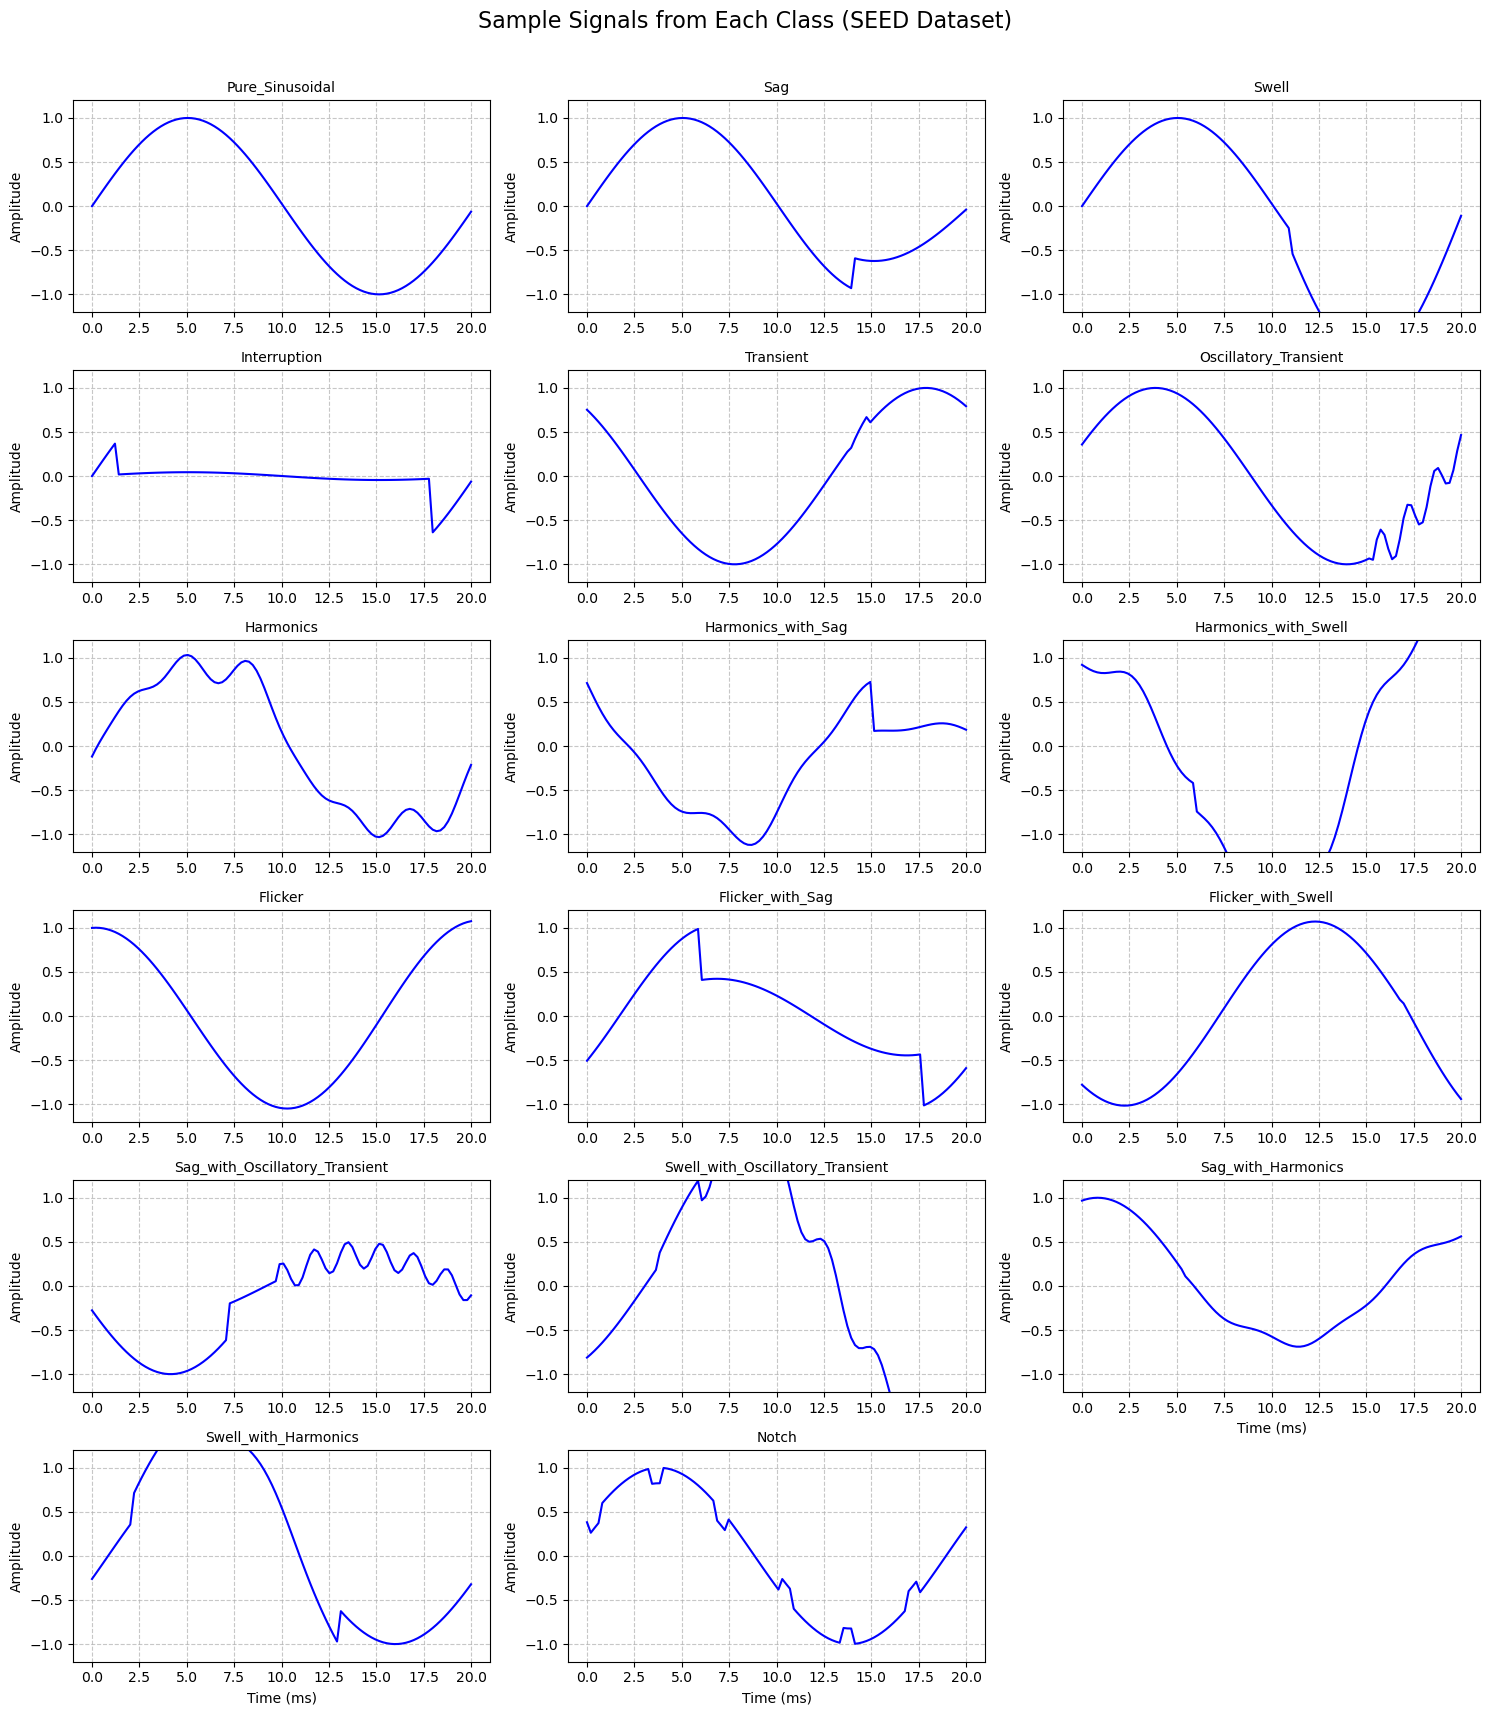

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the dataset path and exact class names
data_dir = 'SEED_CSV_DATA'
classes = [
    'Pure_Sinusoidal', 'Sag', 'Swell', 'Interruption', 'Transient', 
    'Oscillatory_Transient', 'Harmonics', 'Harmonics_with_Sag', 
    'Harmonics_with_Swell', 'Flicker', 'Flicker_with_Sag', 
    'Flicker_with_Swell', 'Sag_with_Oscillatory_Transient', 
    'Swell_with_Oscillatory_Transient', 'Sag_with_Harmonics', 
    'Swell_with_Harmonics', 'Notch'
]

# Dictionaries to store EDA results and a sample signal for plotting
class_counts = {}
missing_data_counts = {}
sample_signals = {}

print("--- Starting Exploratory Data Analysis ---\n")

# Process each class
for cls in classes:
    file_path = os.path.join(data_dir, f"{cls}.csv")
    
    try:
        # Load the CSV file without headers
        df = pd.read_csv(file_path, header=None)
        
        # 1. Count samples per class to check for balance
        num_signals = df.shape[0]
        class_counts[cls] = num_signals
        
        # 2. Look for null values or missing data
        num_missing = df.isnull().sum().sum()
        missing_data_counts[cls] = num_missing
        
        # Store the first signal (row 0) for the grid plot
        sample_signals[cls] = df.iloc[0].values
        
    except FileNotFoundError:
        print(f"Error: Could not find {file_path}")

# Print Balance Report
print("--- Class Balance Report ---")
is_balanced = all(count == 1000 for count in class_counts.values())
print(f"Are all classes perfectly balanced at 1000 samples? {is_balanced}")
for cls, count in class_counts.items():
    if count != 1000:
        print(f"Warning: {cls} has {count} samples.")

# Print Missing Data Report
print("\n--- Missing Data Report ---")
has_missing = any(missing > 0 for missing in missing_data_counts.values())
if not has_missing:
    print("No missing data found in any class. The dataset is clean.")
else:
    for cls, missing in missing_data_counts.items():
        if missing > 0:
            print(f"Warning: {cls} has {missing} missing values.")

# 3. Plot a grid with 1 signal of each class
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(15, 18))
fig.suptitle('Sample Signals from Each Class (SEED Dataset)', fontsize=16)
axes = axes.flatten()

# Generate the time axis representing 20 ms over 100 samples
time_axis = np.linspace(0, 20, 100) 

for i, cls in enumerate(classes):
    ax = axes[i]
    ax.plot(time_axis, sample_signals[cls], color='b')
    ax.set_title(cls, fontsize=10)
    ax.set_ylim(-1.2, 1.2)
    ax.set_ylabel('Amplitude')
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Only show x-axis label for the bottom plots to keep it clean
    if i >= 14:
        ax.set_xlabel('Time (ms)')

# Hide the last empty subplot (17 classes in an 18-grid layout)
axes[17].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

## **1. Time Domain Features**

- **RMS (Root Mean Square):** Excellent for detecting Sags (low RMS) and Swells (high RMS).
    
- **Peak-to-Peak (P2P):** Captures the absolute maximum swing of the signal.
    
- **Zero-Crossing Rate (ZCR):** Highly sensitive to high-frequency Oscillatory Transients and noise.
    
- **Variance, Skewness & Kurtosis:** Skewness measures asymmetry, while Kurtosis measures the "tailedness" (perfect for sharp, sudden Transients and Notches).
    

## **2. Frequency Domain Features**

- **DFT Components (Fundamental & Harmonics):** We will extract the magnitude of the 50 Hz fundamental and specific harmonics (e.g., 3rd, 5th, 7th) using the Fourier Transform.
    
- **THD (Total Harmonic Distortion):** A custom aggregate feature that sums the power of the harmonics relative to the fundamental.
    
- **PSD (Power Spectral Density):** We will extract the peak power density of the signal.

In [4]:
import os
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import periodogram

# Define dataset parameters
data_dir = 'SEED_CSV_DATA'
classes = [
    'Pure_Sinusoidal', 'Sag', 'Swell', 'Interruption', 'Transient', 
    'Oscillatory_Transient', 'Harmonics', 'Harmonics_with_Sag', 
    'Harmonics_with_Swell', 'Flicker', 'Flicker_with_Sag', 
    'Flicker_with_Swell', 'Sag_with_Oscillatory_Transient', 
    'Swell_with_Oscillatory_Transient', 'Sag_with_Harmonics', 
    'Swell_with_Harmonics', 'Notch'
]

fs = 5000  # Sampling frequency (Hz)

def extract_features(signal):
    """Extracts Time and Frequency domain features from a 1D signal array."""
    features = {}
    
    # --- TIME DOMAIN FEATURES ---
    features['RMS'] = np.sqrt(np.mean(signal**2))
    features['P2P'] = np.max(signal) - np.min(signal)
    
    # Zero-Crossing Rate
    zero_crossings = np.where(np.diff(np.sign(signal)))[0]
    features['ZCR'] = len(zero_crossings)
    
    # Statistical Moments
    features['Variance'] = np.var(signal)
    features['Skewness'] = skew(signal)
    features['Kurtosis'] = kurtosis(signal)
    
    # --- FREQUENCY DOMAIN FEATURES ---
    # Perform Fast Fourier Transform (FFT)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / len(signal)
    
    # Because Fs=5000 and N=100, the bins are exactly 50Hz apart.
    # Bin 0: DC (0Hz), Bin 1: 50Hz, Bin 2: 100Hz, Bin 3: 150Hz, etc.
    features['Fund_50Hz_Mag'] = fft_mag[1]
    features['Harmonic_3rd_Mag'] = fft_mag[3]
    features['Harmonic_5th_Mag'] = fft_mag[5]
    features['Harmonic_7th_Mag'] = fft_mag[7]
    
    # Total Harmonic Distortion (THD) roughly estimated
    harmonic_sum = np.sqrt(np.sum(fft_mag[2:]**2))
    features['THD'] = harmonic_sum / (fft_mag[1] + 1e-6) # add epsilon to avoid div zero
    
    # Power Spectral Density (Peak PSD)
    freqs, psd = periodogram(signal, fs)
    features['Peak_PSD'] = np.max(psd)
    
    return features

# --- MAIN EXTRACTION LOOP ---
print("Extracting features... This may take a moment.")
all_features = []

for label_idx, cls in enumerate(classes):
    file_path = os.path.join(data_dir, f"{cls}.csv")
    
    try:
        # Load the CSV file (1000 signals x 100 samples)
        df = pd.read_csv(file_path, header=None)
        
        # Iterate over each row (signal)
        for index, row in df.iterrows():
            sig = row.values
            
            # Extract features for this specific signal
            feat_dict = extract_features(sig)
            
            # Append label strings and numeric encodings
            feat_dict['Class_Name'] = cls
            feat_dict['Label'] = label_idx
            
            all_features.append(feat_dict)
            
    except FileNotFoundError:
        print(f"Skipping {cls}: File not found.")

# Convert the list of dictionaries to a Pandas DataFrame
features_df = pd.DataFrame(all_features)

print("Feature Extraction Complete!")
print(f"Dataset shape: {features_df.shape}")
display(features_df.head())

Extracting features... This may take a moment.
Feature Extraction Complete!
Dataset shape: (17000, 14)


,RMS,P2P,ZCR,Variance,Skewness,Kurtosis,Fund_50Hz_Mag,Harmonic_3rd_Mag,Harmonic_5th_Mag,Harmonic_7th_Mag,THD,Peak_PSD,Class_Name,Label
0,0.707107,2.0,2,0.5,1.951361e-16,-1.5,0.5,4.641002e-17,4.933716e-17,1.380109e-17,5.483170e-16,0.01,Pure_Sinusoidal,0
1,0.707107,2.0,2,0.5,1.951361e-16,-1.5,0.5,4.641002e-17,4.933716e-17,1.380109e-17,5.483170e-16,0.01,Pure_Sinusoidal,0
2,0.707107,2.0,2,0.5,1.951361e-16,-1.5,0.5,4.641002e-17,4.933716e-17,1.380109e-17,5.483170e-16,0.01,Pure_Sinusoidal,0
3,0.707107,2.0,2,0.5,1.951361e-16,-1.5,0.5,4.641002e-17,4.933716e-17,1.380109e-17,5.483170e-16,0.01,Pure_Sinusoidal,0
4,0.707107,2.0,2,0.5,1.951361e-16,-1.5,0.5,4.641002e-17,4.933716e-17,1.380109e-17,5.483170e-16,0.01,Pure_Sinusoidal,0


## Normalization

Normalization is a critical step, especially when preparing data for a Support Vector Machine (SVM). Since SVMs rely on distance metrics (like Euclidean distance) to find the optimal separating hyperplane, features with larger numeric ranges (like Peak PSD) will completely dominate features with smaller ranges (like Skewness or THD) if we don't scale them.

There are two primary methods for Normalization:

1. Z-score (Standardization): Centers the data around a mean of zero with a standard deviation of one. The formula is $z=\frac{(x-\overline{x})}{s}$.
    
2. In a range (Min-Max Scaling): Scales the data to a fixed range, usually [0, 1]. The formula is $z=\frac{x-min(x)}{max(x)-min(x)}$.
    

For SVMs, **Z-score standardization** is generally the best practice because it handles outliers better than Min-Max scaling and aligns well with the assumptions of many underlying optimization algorithms.

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Assuming 'features_df' is the DataFrame from the previous step
print("--- Starting Data Normalization ---")

# 1. Separate the numerical features from the target labels
# We drop 'Class_Name' and 'Label' because we don't want to scale our categorical targets!
X_raw = features_df.drop(columns=['Class_Name', 'Label'])
y_labels = features_df[['Class_Name', 'Label']]

# 2. Initialize the StandardScaler (applies Z-score formula: z = (x - u) / s)
scaler = StandardScaler()

# 3. Fit the scaler to the data and transform it
X_scaled_array = scaler.fit_transform(X_raw)

# 4. Reconstruct the DataFrame with the scaled values and column names
X_scaled_df = pd.DataFrame(X_scaled_array, columns=X_raw.columns)

# 5. Re-attach the target labels to keep our dataset intact
normalized_features_df = pd.concat([X_scaled_df, y_labels], axis=1)

print("Normalization Complete!")
print("\nSample of Normalized Features (Notice the values are now scaled):")
display(normalized_features_df.head())

# Optional: Verify the mean is ~0 and standard deviation is ~1 for a specific feature
sample_feature = 'RMS'
print(f"\nVerification for '{sample_feature}':")
print(f"Mean: {normalized_features_df[sample_feature].mean():.4f} (Should be ~0)")
print(f"Std Dev: {normalized_features_df[sample_feature].std():.4f} (Should be ~1)")

--- Starting Data Normalization ---
Normalization Complete!

Sample of Normalized Features (Notice the values are now scaled):


,RMS,P2P,ZCR,Variance,Skewness,Kurtosis,Fund_50Hz_Mag,Harmonic_3rd_Mag,Harmonic_5th_Mag,Harmonic_7th_Mag,THD,Peak_PSD,Class_Name,Label
0,-0.006952,-0.250547,-0.280287,-0.101935,-0.096266,-0.254065,0.119047,-1.032791,-0.96044,-0.785036,-0.831516,-0.027008,Pure_Sinusoidal,0
1,-0.006952,-0.250547,-0.280287,-0.101935,-0.096266,-0.254065,0.119047,-1.032791,-0.96044,-0.785036,-0.831516,-0.027008,Pure_Sinusoidal,0
2,-0.006952,-0.250547,-0.280287,-0.101935,-0.096266,-0.254065,0.119047,-1.032791,-0.96044,-0.785036,-0.831516,-0.027008,Pure_Sinusoidal,0
3,-0.006952,-0.250547,-0.280287,-0.101935,-0.096266,-0.254065,0.119047,-1.032791,-0.96044,-0.785036,-0.831516,-0.027008,Pure_Sinusoidal,0
4,-0.006952,-0.250547,-0.280287,-0.101935,-0.096266,-0.254065,0.119047,-1.032791,-0.96044,-0.785036,-0.831516,-0.027008,Pure_Sinusoidal,0



Verification for 'RMS':
Mean: -0.0000 (Should be ~0)
Std Dev: 1.0000 (Should be ~1)


## Analysing separability

Visualizing the feature space is one of the most revealing steps in the entire machine learning pipeline. With 17 different classes, it can be difficult for a model to establish clear decision boundaries if the features overlap too heavily.

To evaluate how distinguishable our classes are, we look at **Class Separability**. Conceptually, this is often measured using scatter matrices: the within-class scatter matrix ($S_w$) which measures how tightly grouped the samples are within their own class, and the between-class scatter matrix ($S_b$) which measures how far apart the different class centers are from the global mean. A good feature space has tight clusters that are far apart from each other.

To visualize this high-dimensional space (our 11 features), we will use **Principal Component Analysis (PCA)**. PCA reduces the dimensionality of the feature vector by losing as little information as possible. It does this by creating new variables (Principal Components) that are linear combinations of the originals, built in order of importance according to their variability. In short, PCA maximizes variance and creates variables in the new space that are not correlated.

In the next block of code, we will perform PCA on our normalized data and generate two crucial plots:

1. **Cumulative Explained Variance:** This helps us decide how many Principal Components to keep by showing the percentage of total variance captured.
    
2. **2D PCA Scatter Plot:** This projects our 11-dimensional data down to 2 dimensions so we can visually inspect the class separability.

--- Starting Principal Component Analysis (PCA) ---


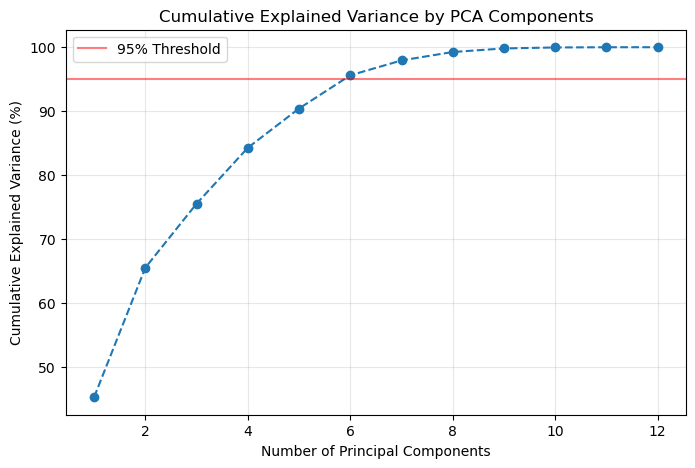

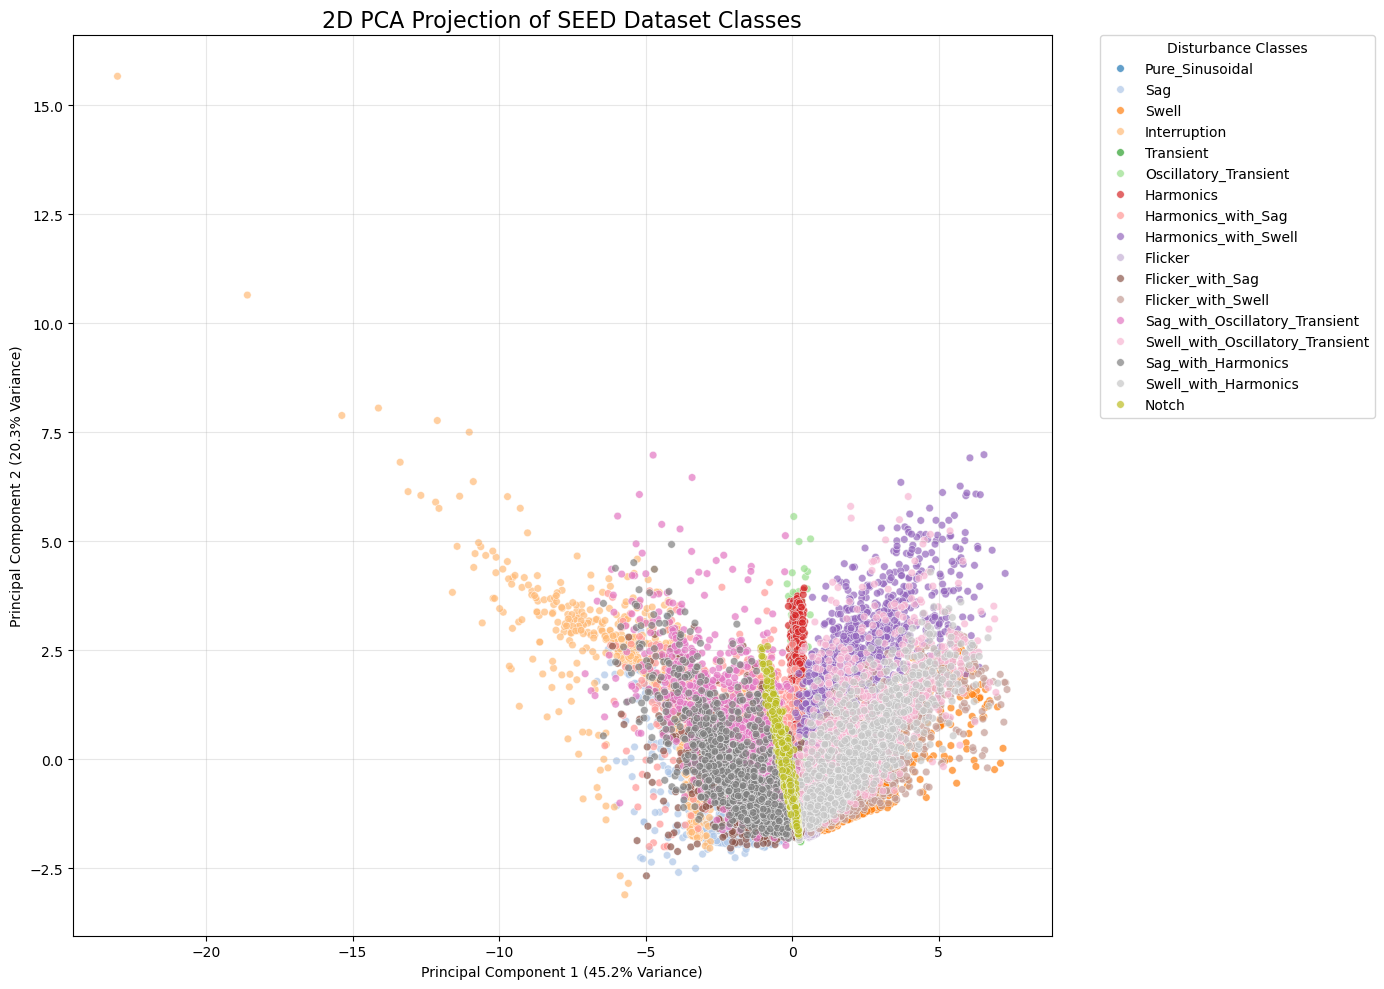

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

print("--- Starting Principal Component Analysis (PCA) ---")

# 1. Initialize PCA (we'll compute all components first to see the variance distribution)
pca_full = PCA()
# Use the normalized features from the previous step
X_pca_full = pca_full.fit_transform(X_scaled_df)

# 2. Plot the Cumulative Explained Variance
# This helps us determine the optimal number of components
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.axhline(y=95, color='r', linestyle='-', alpha=0.5, label='95% Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Project data to 2D for Visualizing Class Separability
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_df)

# Add the 2D components back to a DataFrame for easy plotting with Seaborn
pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
pca_df['Class_Name'] = normalized_features_df['Class_Name']

# 4. Plot the 2D Feature Space
plt.figure(figsize=(14, 10))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Class_Name',
    palette='tab20', # A colormap with enough distinct colors for 17 classes
    data=pca_df,
    alpha=0.7,
    s=30
)

plt.title('2D PCA Projection of SEED Dataset Classes', fontsize=16)
plt.xlabel(f"Principal Component 1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Disturbance Classes")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

## SVM preliminary results

In [9]:
import time
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA

print("--- Starting SVM Performance Comparison ---\n")

# 1. Prepare the Data
# Ensure we use the numeric labels for training
X = X_scaled_df
y = y_labels['Label']
class_names = classes # List of strings from the first step

# Split into Training (80%) and Testing (20%) sets
# stratify=y ensures all 17 classes are equally represented in the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# OPTION A: Train on All 11 Original Features
# ==========================================
print("Training Model A: All 11 Original Normalized Features...")
svm_original = SVC(kernel='rbf', random_state=42)

start_time_A = time.time()
svm_original.fit(X_train, y_train)
train_time_A = time.time() - start_time_A

y_pred_A = svm_original.predict(X_test)
accuracy_A = accuracy_score(y_test, y_pred_A)

print(f"Model A Training Time: {train_time_A:.4f} seconds")
print(f"Model A Accuracy: {accuracy_A * 100:.2f}%\n")


# ==========================================
# OPTION B: Train on 6 Principal Components (95% Variance)
# ==========================================
print("Training Model B: 6 PCA Components...")

# Fit PCA on the training data, then transform both train and test
pca_6 = PCA(n_components=6, random_state=42)
X_train_pca = pca_6.fit_transform(X_train)
X_test_pca = pca_6.transform(X_test)

svm_pca = SVC(kernel='rbf', random_state=42)

start_time_B = time.time()
svm_pca.fit(X_train_pca, y_train)
train_time_B = time.time() - start_time_B

y_pred_B = svm_pca.predict(X_test_pca)
accuracy_B = accuracy_score(y_test, y_pred_B)

print(f"Model B Training Time: {train_time_B:.4f} seconds")
print(f"Model B Accuracy: {accuracy_B * 100:.2f}%\n")


# ==========================================
# FINAL COMPARISON REPORT
# ==========================================
print("-" * 40)
print("          PERFORMANCE SUMMARY           ")
print("-" * 40)
print(f"Option A (12 Features) : Accuracy = {accuracy_A*100:.2f}%, Time = {train_time_A:.4f} s")
print(f"Option B (6 PCA Comps) : Accuracy = {accuracy_B*100:.2f}%, Time = {train_time_B:.4f} s")
print("-" * 40)

# Optional: Print detailed report for Option A to see which classes struggle
# print("\nDetailed Classification Report (Option A):")
# print(classification_report(y_test, y_pred_A, target_names=class_names))

--- Starting SVM Performance Comparison ---

Training Model A: All 11 Original Normalized Features...
Model A Training Time: 0.7366 seconds
Model A Accuracy: 72.47%

Training Model B: 6 PCA Components...
Model B Training Time: 0.7382 seconds
Model B Accuracy: 69.29%

----------------------------------------
          PERFORMANCE SUMMARY           
----------------------------------------
Option A (12 Features) : Accuracy = 72.47%, Time = 0.7366 s
Option B (6 PCA Comps) : Accuracy = 69.29%, Time = 0.7382 s
----------------------------------------


--- Generating Confusion Matrix for Option A ---


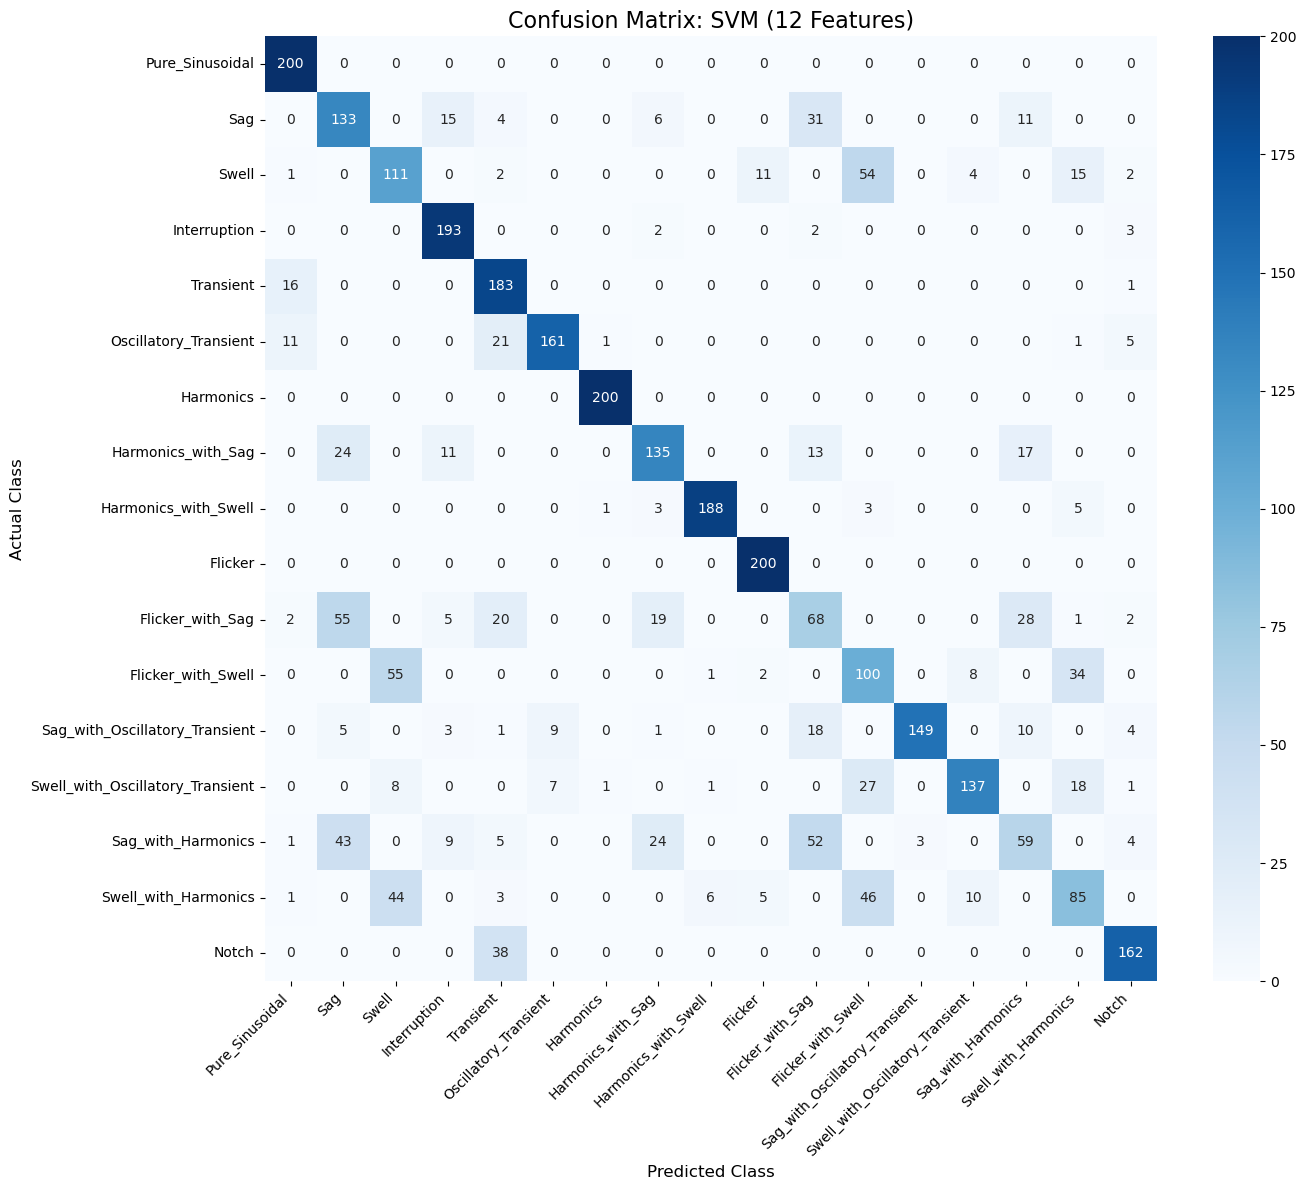

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("--- Generating Confusion Matrix for Option A ---")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_A)

# Plotting using Seaborn
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix: SVM (12 Features)', fontsize=16)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Final Performance Summary

    #       Model / Architecture            Accuracy (%)
    0	CNN	                            84	
    1	CRNN	                            91	
    2	MobileNetV2	                    70	
    3       SVM                                 72.47